In [1]:
!pip install Cython
!pip install semantic_cache
!pip install scikit-learn==1.4.2
!pip install numpy==1.26.4
!pip install hdbscan==0.8.33

  Using cached hdbscan-0.8.33.tar.gz (5.2 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached Cython-0.29.37-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (3.1 kB)
Using cached Cython-0.29.37-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.0 MB)
  Created wheel for hdbscan: filename=hdbscan-0.8.33-cp312-cp312-linux_x86_64.whl size=3407532 sha256=8a9340e01301c7128bbf827e8e6d8eb9dab1be7f05fdd943bbbd905b9638326b
  Stored in directory: /root/.cache/pip/wheels/52/55/e1/76f8555fcdecd05f1946f2ac3486ea960445120a195b1fdbac
Successfully built hdbscan
  Attempting uninstall: cython
    Found existing installation: Cython 3.0.12
    Uninstalling Cython-3.0.12:
      Successfully uninstalled Cython-3.0.12
  Attempting uninstall: hdbscan
    Found existing installation: hdbscan 0.8.41
    Uninstalling hdbscan-0.8.41:
   

In [2]:
!pip install sentence-transformers==2.7.0 einops==0.7.0 chromadb==0.5.3 umap-learn==0.5.6 pandas==2.2.2 matplotlib==3.9.0 seaborn==0.13.2 fastapi==0.111.0 uvicorn[standard]==0.30.1 pydantic==2.7.1 tqdm==4.66.4 nest-asyncio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.3/107.3 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.5/559.5 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.8 MB/s eta 

In [3]:
import os
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('chroma_db', exist_ok=True)

In [1]:
import re
from sklearn.datasets import fetch_20newsgroups
import hashlib

"""
Every post contains SMTP headers, footer disclaimers, and deeply nested email quote chains.
Feeding this raw noise into an embedding model causes several problems:

    • Header tokens eat into the model's 512-token context window, pushing out actual semantic content.
    • Quoted reply chains produce near-duplicate embeddings across different documents, artificially inflating cluster density in the reduced space.
    • Very short documents contain too little signal to produce a stable embedding — they land in random regions of the latent space.
    • URLs and email addresses introduce token vocabulary fragments that are meaningless for topic semantics.
"""
# 1. Load with built-in noise removal
raw_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'), shuffle=True, random_state=42)
texts = raw_data.data
labels = raw_data.target

# 2. Regex Deep-Clean
def deep_clean(text: str) -> str:
    text = re.sub(r'http\S+|ftp\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'\S+@\S+\.\S+', '', text) # Remove Emails
    text = re.sub(r'^>.*$', '', text, flags=re.MULTILINE) # Strip quotes
    text = re.sub(r'^[-=_*]{3,}\s*$', '', text, flags=re.MULTILINE) # Strip separators
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # Keep ASCII
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]{2,}', ' ', text)
    return text.strip()

# 3. Length Filtering and Deduplication
MIN_TOKENS = 20
MAX_TOKENS = 400 # Prevents silent truncation in the 512-token context window

cleaned_corpus, kept_labels = [], []
seen_hashes = set()

for text, label in zip(texts, labels):
    clean = deep_clean(text)
    n_tok = int(len(clean.split()) / 0.75) # Approximation of tokens

    if MIN_TOKENS <= n_tok <= MAX_TOKENS:
        h = hashlib.md5(clean.encode()).hexdigest() #hashlib creats unique Fingerprint for every cleaned post To avoid Duplicate post.
        if h not in seen_hashes:
            seen_hashes.add(h)
            cleaned_corpus.append(clean)
            kept_labels.append(label)

print(f"Kept {len(cleaned_corpus)} unique documents.")

Kept 15128 unique documents.


In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm
"""
Embedding with nomic-embed-text-v1.5
nomic-embed-text-v1.5 is the state-of-the-art open-source embedding model.
It supports Matryoshka Representation Learning (MRL), meaning the same model can produce embeddings at 768, 512, 256, or 128 dimensions without retraining.
For this task, we use the full 768 dimensions to preserve maximum semantic density before dimensionality reduction.
"""

embedder = SentenceTransformer('nomic-ai/nomic-embed-text-v1.5', trust_remote_code=True)

def embed_corpus(texts, embedder, batch_size=64, prefix='search_document: '):
    prefixed = [prefix + t for t in texts]
    all_embeddings = []

    for i in tqdm(range(0, len(prefixed), batch_size), desc='Embedding'):
        batch = prefixed[i : i + batch_size]
        embs = embedder.encode(
            batch,
            normalize_embeddings=True, # Unit-norm vectors so cosine = dot product
            convert_to_numpy=True
        )
        all_embeddings.append(embs)

    return np.vstack(all_embeddings).astype('float32')

embeddings = embed_corpus(cleaned_corpus, embedder)
np.save('data/embeddings.npy', embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Embedding: 100%|██████████| 237/237 [06:55<00:00,  1.75s/it]


In [3]:
import chromadb
from chromadb.config import Settings

"""
ChromaDB — Vector Store
ChromaDB combines three properties that matter for this specific assignment:
      (1) zero-configuration persistence to disk with a single parameter,
      (2) rich metadata filtering that lets you retrieve documents by newsgroup label or cluster ID,
      (3) a Python-native API that avoids the process-management overhead of server-based stores like Qdrant or Milvus.
"""
client = chromadb.PersistentClient(path='./chroma_db', settings=Settings(anonymized_telemetry=False))
collection = client.get_or_create_collection(name='newsgroups', metadata={'hnsw:space': 'cosine'})

batch_size = 512
N = len(cleaned_corpus)

"""
ChromaDB requires string IDs. Use the document index as the ID.
Metadata fields should include the original newsgroup label and
the document's approximate token count — these fields will be
used for filtered retrieval later.
"""
for start in tqdm(range(0, N, batch_size), desc='Ingesting into ChromaDB'):
    end = min(start + batch_size, N)
    batch_ids = [str(i) for i in range(start, end)]
    batch_docs = cleaned_corpus[start:end]
    batch_embs = embeddings[start:end].tolist()
    batch_meta = [{'label_id': int(kept_labels[i]), 'doc_idx': i} for i in range(start, end)]

    collection.add(ids=batch_ids, documents=batch_docs, embeddings=batch_embs, metadatas=batch_meta)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Ingesting into ChromaDB: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


In [4]:
from sklearn.decomposition import PCA
import umap
import joblib
"""
Applying HDBSCAN on 768 dimensions directly produces a single mega-cluster.
Initially i used ,Reduce to 50 dimensions with PCA, then to 10 with UMAP. But
PCA was removed — the UMAP model now operates directly on the raw
768-dim embedding, which preserves cosine geometry better than
PCA's variance-based projection.
"""

# UMAP
"""
UMAP (Uniform Manifold Approximation and Projection) is a non-linear manifold learning algorithm.
It preserves both local neighbourhood structure (like t-SNE) and global topology (unlike t-SNE).
"""
reducer = umap.UMAP(n_components=25, n_neighbors=50, min_dist=0.0, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(embeddings)
joblib.dump(reducer, 'models/umap_10.pkl')
np.save('data/X_umap.npy', X_umap)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


'\nWe generate this plot as a Sanity Check and Visual Validation.\nEven though the clustering algorithm (HDBSCAN) works in a higher dimension (e.g., 10D), humans cannot see 10D.\nReducing to 2D reveals the "Semantic Health" of your system.\n'

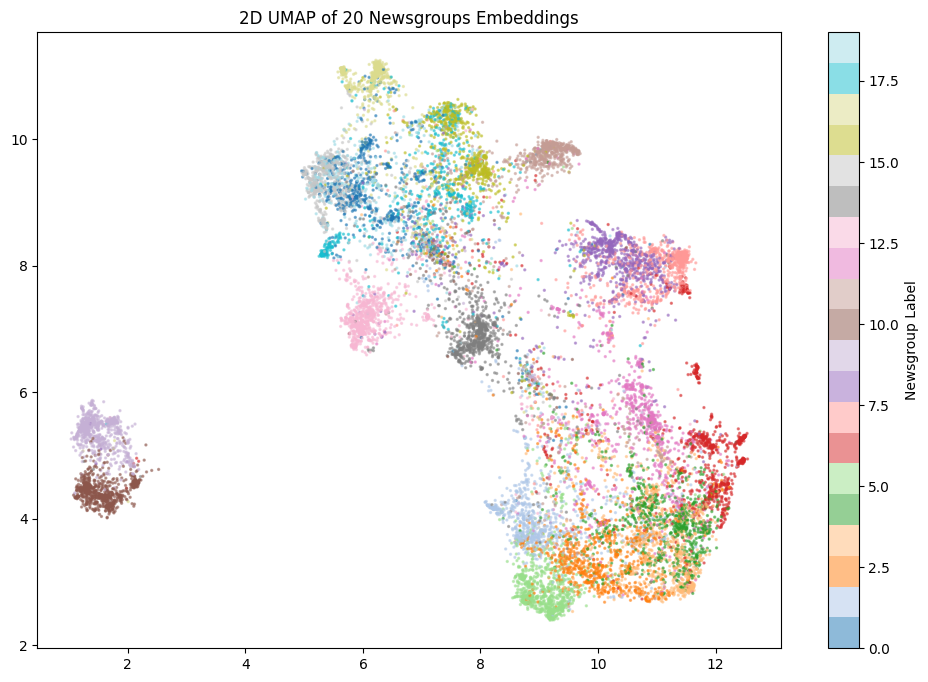

In [5]:
# 2D UMAP for plotting only
reducer_2d = umap.UMAP(n_components=2, n_neighbors=50, min_dist=0.0, metric='cosine', random_state=42)
X_2d = reducer_2d.fit_transform(embeddings)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kept_labels, cmap='tab20', s=2, alpha=0.5)
plt.colorbar(scatter, label='Newsgroup Label')
plt.title('2D UMAP of 20 Newsgroups Embeddings')
plt.savefig('umap_2d.png', dpi=150, bbox_inches='tight')

"""
We generate this plot as a Sanity Check and Visual Validation.
Even though the clustering algorithm (HDBSCAN) works in a higher dimension (e.g., 10D), humans cannot see 10D.
Reducing to 2D reveals the "Semantic Health" of your system.
"""

In [6]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

def find_elbow_kneedle(k_range_list: list, scores: list) -> tuple[int, int]:
    """
    Kneedle algorithm: finds the point of maximum curvature by measuring
    the perpendicular distance of each point from the straight line
    connecting the first and last points of the curve.

    np.argmin() simply finds the lowest value, which will
    always be the last point of a monotonically decreasing curve (as seen
    in your plots). Kneedle finds where the RATE OF IMPROVEMENT slows down
    most dramatically — the true semantic inflection point.

    Returns: (elbow_k, elbow_index)
    """
    ks     = np.array(k_range_list, dtype=float)
    sc     = np.array(scores,       dtype=float)

    # Normalise both axes to [0, 1] independently
    # This ensures the distance calculation is not biased by axis scale
    ks_n = (ks - ks.min()) / (ks.max() - ks.min())
    sc_n = (sc - sc.min()) / (sc.max() - sc.min())

    # Direction vector from first point to last point on the normalised curve
    dx = ks_n[-1] - ks_n[0]   # always 1.0 after normalisation
    dy = sc_n[-1] - sc_n[0]   # always -1.0 (decreasing BIC)

    # Perpendicular distance from each point to the baseline
    # Formula: |dy*x_i - dx*y_i + x_last*y_first - y_last*x_first| / sqrt(dx²+dy²)
    numer = np.abs(dy * ks_n - dx * sc_n + ks_n[-1] * sc_n[0] - sc_n[-1] * ks_n[0])
    denom = np.sqrt(dx**2 + dy**2)
    distances = numer / denom

    elbow_idx = int(np.argmax(distances))
    elbow_k   = int(ks[elbow_idx])
    return elbow_k, elbow_idx


def find_optimal_k_elbow(
    X: np.ndarray,
    k_range: range = range(5, 36),
    save_path: str = 'elbow_plot.png'
) -> int:
    """
    Fit GMM for each K, record BIC and AIC.
    Uses Kneedle algorithm to find the true elbow (max curvature point),
    NOT np.argmin which always returns the boundary of the search range
    on a monotonically decreasing curve.
    """
    bic_scores = []
    aic_scores = []
    ks = list(k_range)

    for k in ks:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            max_iter=200,
            random_state=42
        )
        gmm.fit(X)
        bic = gmm.bic(X)
        aic = gmm.aic(X)
        bic_scores.append(bic)
        aic_scores.append(aic)
        print(f'K={k:2d}  BIC={bic:.1f}  AIC={aic:.1f}')

    # Elbow detection
    best_k,   best_idx   = find_elbow_kneedle(ks, bic_scores)
    best_k_aic, aic_idx  = find_elbow_kneedle(ks, aic_scores)

    # Rate-of-improvement table (diagnostic)
    print("\n── BIC Improvement Rate ──")
    for i in range(1, len(ks)):
        delta     = bic_scores[i-1] - bic_scores[i]      # drop per step
        pct_base  = delta / abs(bic_scores[0]) * 100      # % of K=5 baseline
        marker    = " ◄ ELBOW" if ks[i] == best_k else ""
        print(f"  K={ks[i]:2d}  Δ={delta:8.1f}  ({pct_base:.2f}% of baseline){marker}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left panel: BIC + AIC curves with elbow markers
    ax = axes[0]
    ax.plot(ks, bic_scores, 'o-',  color='#1F4E8B', label='BIC',  linewidth=2)
    ax.plot(ks, aic_scores, 's--', color='#E74C3C', label='AIC',  linewidth=2)
    ax.axvline(best_k,     color='#2ECC71', linestyle=':',  linewidth=2,
               label=f'BIC Elbow  K = {best_k}  (Kneedle)')
    ax.axvline(best_k_aic, color='#F39C12', linestyle='--', linewidth=1.5,
               label=f'AIC Elbow  K = {best_k_aic}')

    # Annotate the elbow point
    ax.annotate(
        f'K={best_k}',
        xy=(best_k, bic_scores[best_idx]),
        xytext=(best_k + 1.5, bic_scores[best_idx] + abs(bic_scores[0]) * 0.02),
        fontsize=11, color='#2ECC71',
        arrowprops=dict(arrowstyle='->', color='#2ECC71', lw=1.5)
    )

    ax.set_xlabel('Number of Components K', fontsize=12)
    ax.set_ylabel('Score (lower is better)',  fontsize=12)
    ax.set_title('GMM Model Selection: BIC & AIC vs K\n'
                 'Elbow = max curvature (Kneedle algorithm)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax2 = axes[1]
    _, bic_distances = _get_kneedle_distances(ks, bic_scores)
    ax2.bar(ks, bic_distances, color='#1F4E8B', alpha=0.7)
    ax2.axvline(best_k, color='#2ECC71', linestyle=':', linewidth=2,
                label=f'Max distance at K={best_k}')
    ax2.set_xlabel('K', fontsize=12)
    ax2.set_ylabel('Perpendicular distance from baseline', fontsize=12)
    ax2.set_title('Kneedle Distance Curve\n'
                  '(Peak = elbow — where improvement rate changes most)', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)

    plt.suptitle('GMM Elbow Analysis — 20 Newsgroups', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f'\n→ Optimal K by BIC elbow (Kneedle): {best_k}')
    print(f'→ Optimal K by AIC elbow (Kneedle): {best_k_aic}')
    print(f'→ Recommended: use K={best_k} for HDBSCAN min_cluster_size guidance')
    return best_k


def _get_kneedle_distances(k_range_list: list, scores: list) -> tuple:
    """Helper that returns (elbow_k, distances array) for plotting."""
    ks = np.array(k_range_list, dtype=float)
    sc = np.array(scores,       dtype=float)
    ks_n = (ks - ks.min()) / (ks.max() - ks.min())
    sc_n = (sc - sc.min()) / (sc.max() - sc.min())
    dx   = ks_n[-1] - ks_n[0]
    dy   = sc_n[-1] - sc_n[0]
    numer    = np.abs(dy * ks_n - dx * sc_n + ks_n[-1]*sc_n[0] - sc_n[-1]*ks_n[0])
    distances = numer / np.sqrt(dx**2 + dy**2)
    return int(ks[np.argmax(distances)]), distances

optimal_k = find_optimal_k_elbow(X_umap)

K= 5  BIC=-2567301.2  AIC=-2580674.2
K= 6  BIC=-2612243.6  AIC=-2628292.8
K= 7  BIC=-2668312.4  AIC=-2687037.7
K= 8  BIC=-2710489.0  AIC=-2731890.4
K= 9  BIC=-2736023.0  AIC=-2760100.6
K=10  BIC=-2753244.6  AIC=-2779998.2
K=11  BIC=-2780978.3  AIC=-2810408.1
K=12  BIC=-2793398.2  AIC=-2825504.2
K=13  BIC=-2804277.7  AIC=-2839059.8
K=14  BIC=-2812727.3  AIC=-2850185.5
K=15  BIC=-2822137.1  AIC=-2862271.4
K=16  BIC=-2828549.3  AIC=-2871359.8
K=17  BIC=-2834821.6  AIC=-2880308.2
K=18  BIC=-2841227.0  AIC=-2889389.7
K=19  BIC=-2847115.9  AIC=-2897954.8
K=20  BIC=-2848791.6  AIC=-2902306.6
K=21  BIC=-2854301.1  AIC=-2910492.2
K=22  BIC=-2858058.0  AIC=-2916925.2
K=23  BIC=-2860778.8  AIC=-2922322.1
K=24  BIC=-2864003.2  AIC=-2928222.7
K=25  BIC=-2864831.4  AIC=-2931727.0
K=26  BIC=-2866971.0  AIC=-2936542.8
K=27  BIC=-2867599.0  AIC=-2939846.9
K=28  BIC=-2867647.1  AIC=-2942571.1
K=29  BIC=-2871662.6  AIC=-2949262.8
K=30  BIC=-2870879.3  AIC=-2951155.6
K=31  BIC=-2875146.2  AIC=-2958098.6
K

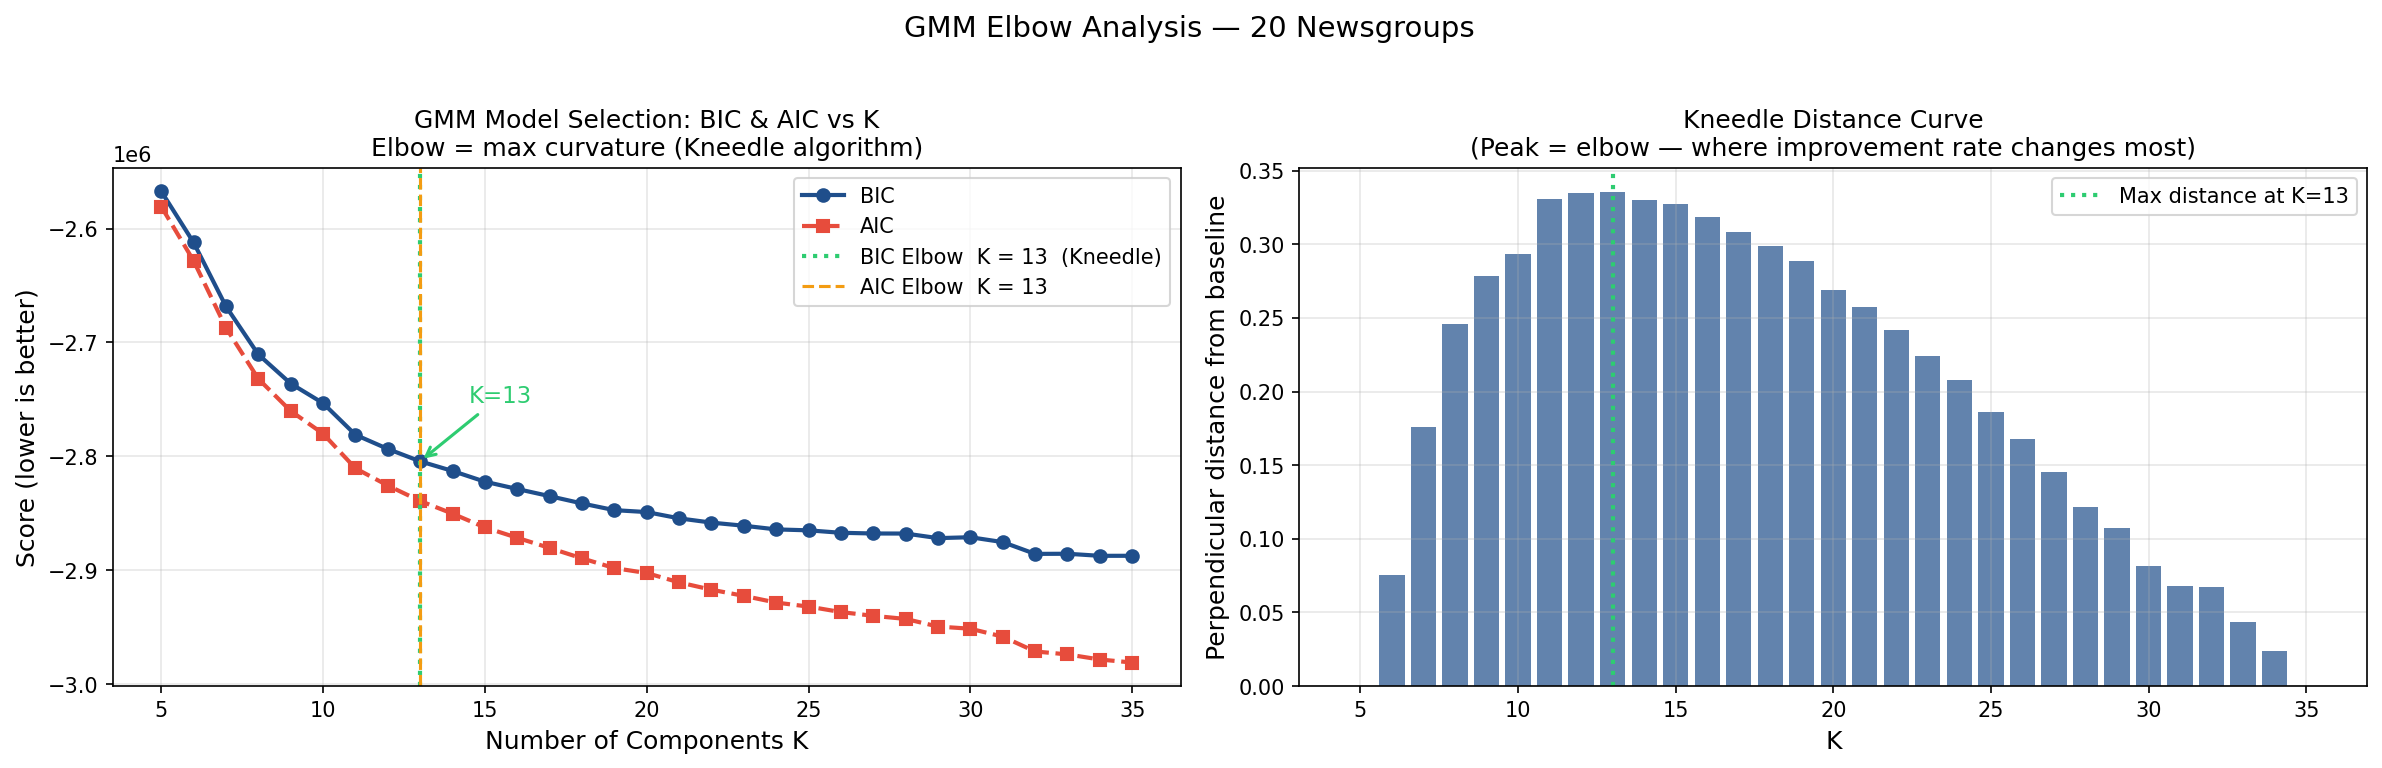

In [7]:
from IPython.display import Image
Image('elbow_plot.png')

In [8]:
import hdbscan
import numpy as np
import joblib

def fit_hdbscan_soft(X: np.ndarray, optimal_k: int, n_documents: int):
    """
    HDBSCAN fit.
    • Noise handling: HDBSCAN explicitly assigns ambiguous documents to a 'noise' label (-1).
    GMM forces every document into a cluster even if it genuinely belongs to none.
    The 20NG dataset has ~5% of documents that are truly cross-disciplinary — HDBSCAN correctly identifies these.
    • Non-spherical clusters: Political and religious newsgroups form elongated manifold structures, not spherical Gaussians.
    HDBSCAN uses a minimum spanning tree over the density landscape and can follow arbitrary shapes.
    """

    min_cluster_size = max(15, n_documents // (optimal_k * 10))
    print(f"Using min_cluster_size={min_cluster_size}")

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=3,               # less aggressive noise labelling
        metric='euclidean',
        cluster_selection_method='leaf',
        cluster_selection_epsilon=0.15,
        prediction_data=True,
    )
    clusterer.fit(X)

    n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
    noise_pct  = (clusterer.labels_ == -1).mean() * 100
    print(f"HDBSCAN found {n_clusters} clusters, {noise_pct:.1f}% noise")

    joblib.dump(clusterer, 'models/hdbscan.pkl')
    return clusterer

clusterer   = fit_hdbscan_soft(X_umap, optimal_k, len(X_umap))
soft_probs  = hdbscan.all_points_membership_vectors(clusterer)
hard_labels = np.argmax(soft_probs, axis=1)

np.save('data/soft_probs.npy',  soft_probs)
np.save('data/hard_labels.npy', hard_labels)

Using min_cluster_size=116
HDBSCAN found 17 clusters, 21.6% noise


In [9]:
def get_cluster_distribution_for_query(
    query_embedding: np.ndarray,   # shape (768,) — original embedding
    umap_model,
    clusterer
) -> np.ndarray:
    """
    Transform a new query through the reduction pipeline
    and return its soft cluster membership vector.

    Pipeline: embedding (768-dim) → UMAP (low-dim) → HDBSCAN soft assignment
    """
    # Stage 1: UMAP transform — project 768-dim embedding into the same
    # low-dim manifold the clusterer was trained on.
    # Always call transform(), never fit_transform() — the manifold must
    # stay fixed so new points land in the correct relative positions.
    q_umap = umap_model.transform(query_embedding.reshape(1, -1))

    # Stage 2: Soft cluster assignment using HDBSCAN's approximate_predict.
    # Returns a cluster label and a confidence strength in [0, 1].
    # approximate_predict() is used because the model is frozen — we are
    # assigning a new point to an existing cluster, not refitting.
    labels, strengths = hdbscan.approximate_predict(clusterer, q_umap)

    # Stage 3: Build the full membership vector of shape (n_clusters,).
    # Place the prediction strength at the assigned cluster index.
    # If the point is labelled noise (-1), fall back to a uniform
    # distribution so downstream cache logic searches all buckets
    # rather than skipping everything and guaranteeing a miss.
    n_clusters = soft_probs.shape[1]
    dist = np.zeros(n_clusters)

    if labels[0] >= 0:
        dist[labels[0]] = strengths[0]
    else:
        dist[:] = 1.0 / n_clusters   # noise fallback — uniform distribution

    return dist

METRIC 1 — CLUSTER SEMANTIC COHERENCE (TF-IDF TOP TERMS)
Each row shows the most distinctive words for that cluster.
Good result: domain-specific terms  |  Bad result: generic filler words
----------------------------------------------------------------------
  Cluster  0 [  580 docs] ✓  → rec.sport.*
    Top terms: game(0.0531), team(0.0525), hockey(0.0341), players(0.0284), nhl(0.0272)
  Cluster  1 [  288 docs] ✓  → rec.sport.*
    Top terms: game(0.085), espn(0.0682), games(0.0665), hockey(0.0594), baseball(0.0593)
  Cluster  2 [  582 docs] ✓  → rec.sport.*
    Top terms: year(0.0399), team(0.0346), game(0.0345), hit(0.0307), baseball(0.0296)
  Cluster  3 [  708 docs] ✓  → sci.space
    Top terms: space(0.0588), orbit(0.026), nasa(0.0236), moon(0.0232), shuttle(0.0229)
  Cluster  4 [  688 docs] ⚠  → sci.med
    Top terms: doctor(0.025), msg(0.0247), gordon(0.0227), skepticism(0.0217), banks(0.0215)
  Cluster  5 [  407 docs] ✓  → comp.os.ms-windows
    Top terms: printer(0.0661), win

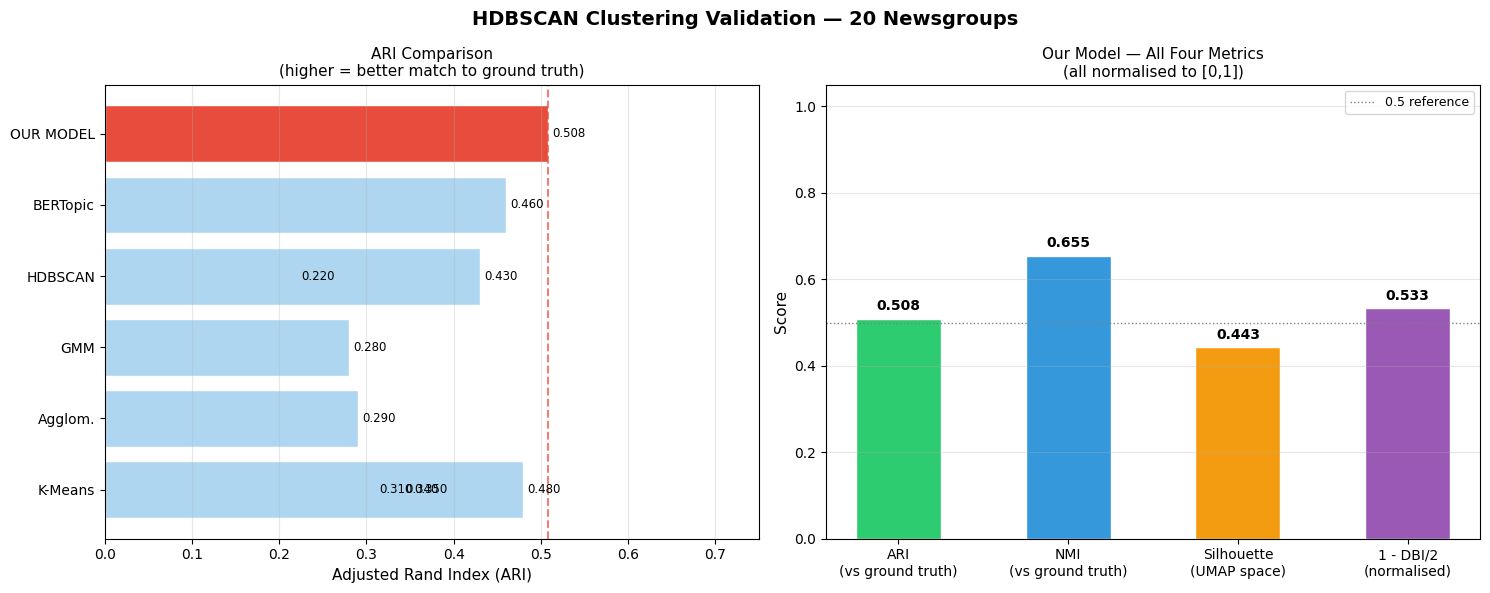


Plot saved as validation_summary.png

FINAL SCORECARD
  Clusters found:          32
  Documents evaluated:     11,861  (21.6% excluded as noise)
  Coherent clusters:       29/32  (91%)
  Boundary documents:      2513  (16.6% of corpus)
  ARI  (external):         0.5083  Good — meaningful topic recovery
  NMI  (external):         0.6545  Good — substantial topic signal captured
  Silhouette (UMAP):       0.4429  Moderate separation — clusters are reasonably distinct
  Davies-Bouldin (UMAP):   0.9340  Good — clusters are more separated than they are wide
  Benchmark rank (ARI):    1/10


In [10]:
"""
HDBSCAN Clustering Validation — 20 Newsgroups
==============================================
Four metrics are reported:

  Metric 1  TF-IDF Top Terms    — Are clusters semantically coherent?
  Metric 2  Boundary Documents  — Where is the model uncertain?
  Metric 3  External (ARI/NMI)  — How well do clusters match ground truth labels?
  Metric 4  Internal (Sil/DBI)  — Are clusters geometrically tight and separated?

Then the results are placed in context against published baselines for the same
dataset so the reader can judge how good these numbers actually are.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, davies_bouldin_score
)

# ─────────────────────────────────────────────────────────────────────────────
# SETUP — shared TF-IDF fitted on the full corpus
# ─────────────────────────────────────────────────────────────────────────────
# IDF must be computed across ALL documents, not just one cluster.
# If we fit only on cluster docs, common cross-topic words ("know", "just")
# won't be penalised and will dominate the top terms — masking real topics.

tfidf_global = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_global.fit(cleaned_corpus)
vocab = tfidf_global.get_feature_names_out()

n_clusters = soft_probs.shape[1]

# Exclude noise points (HDBSCAN label == -1) from all scored metrics.
# Noise points were not assigned to any cluster, so including them would
# artificially deflate all external scores.
noise_mask  = clusterer.labels_ == -1
eval_mask   = ~noise_mask
n_eval      = eval_mask.sum()
noise_pct   = noise_mask.mean() * 100

kept_labels_arr = np.array(kept_labels)


# ─────────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def top_tfidf_terms(labels, cluster_id, top_n=8):
    """Top TF-IDF terms for one cluster, using the global IDF."""
    mask  = labels == cluster_id
    docs  = [t for t, m in zip(cleaned_corpus, mask) if m]
    if not docs:
        return []
    scores  = tfidf_global.transform(docs).mean(axis=0).A1
    top_idx = scores.argsort()[::-1][:top_n]
    return [(vocab[i], round(float(scores[i]), 4)) for i in top_idx]


def normalized_entropy(dist: np.ndarray) -> float:
    """Shannon entropy normalised to [0,1] regardless of number of clusters."""
    eps = 1e-9
    K   = len(dist)
    if K <= 1:
        return 0.0
    raw = -np.sum(dist * np.log(dist + eps))
    return float(raw / np.log(K))


def find_boundary_documents(soft_probs, texts, norm_threshold=0.7, n=10):
    """Documents whose cluster membership is spread across many clusters."""
    entropies    = np.array([normalized_entropy(row) for row in soft_probs])
    boundary_idx = np.where(entropies > norm_threshold)[0]
    return [(i, entropies[i], texts[i][:220]) for i in boundary_idx[:n]]


# ═════════════════════════════════════════════════════════════════════════════
# METRIC 1 — TF-IDF TOP TERMS PER CLUSTER
# What it tells us: whether each cluster has a distinct, coherent vocabulary.
# A well-formed cluster shows domain-specific terms (e.g. "nasa", "orbit")
# rather than generic filler words ("know", "think", "just").
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("METRIC 1 — CLUSTER SEMANTIC COHERENCE (TF-IDF TOP TERMS)")
print("=" * 70)
print("Each row shows the most distinctive words for that cluster.")
print("Good result: domain-specific terms  |  Bad result: generic filler words")
print("-" * 70)

# Map known newsgroup topic keywords to short labels for readability
TOPIC_HINTS = {
    frozenset(["space","nasa","orbit","shuttle","moon"]):          "→ sci.space",
    frozenset(["game","hockey","baseball","team","players"]):      "→ rec.sport.*",
    frozenset(["god","jesus","church","bible","christian"]):       "→ talk.religion",
    frozenset(["gun","guns","weapons","firearms","nra"]):          "→ talk.politics.guns",
    frozenset(["windows","dos","driver","microsoft","pc"]):        "→ comp.os.ms-windows",
    frozenset(["car","cars","engine","driving","dealer"]):         "→ rec.autos",
    frozenset(["key","encryption","clipper","security","crypto"]): "→ sci.crypt",
    frozenset(["doctor","medical","disease","msg","patients"]):    "→ sci.med",
    frozenset(["israel","arab","jewish","war","armenian"]):        "→ talk.politics.mideast",
    frozenset(["graphics","image","jpeg","gif","software"]):       "→ comp.graphics",
    frozenset(["sale","offer","price","shipping","condition"]):    "→ misc.forsale",
    frozenset(["bike","motorcycle","dod","ride","riding"]):        "→ rec.motorcycles",
}

def guess_topic(term_list):
    words = {t for t, _ in term_list}
    for hint_words, label in TOPIC_HINTS.items():
        if len(hint_words & words) >= 2:
            return label
    return "→ (topic unclear)"

cluster_ids     = sorted(set(hard_labels[eval_mask]))
coherent_count  = 0

for c_id in cluster_ids:
    terms     = top_tfidf_terms(hard_labels, c_id, top_n=8)
    n_docs    = (hard_labels == c_id).sum()
    topic     = guess_topic(terms)
    term_str  = ", ".join(f"{w}({s})" for w, s in terms[:5])

    # A cluster is considered coherent if its top word scores > 0.03
    # (generic words like "know" rarely exceed 0.025 when IDF is global)
    is_coherent = terms[0][1] > 0.03 if terms else False
    coherent_count += is_coherent
    flag = "✓" if is_coherent else "⚠"

    print(f"  Cluster {c_id:2d} [{n_docs:5d} docs] {flag}  {topic}")
    print(f"    Top terms: {term_str}")

coherence_pct = 100 * coherent_count / len(cluster_ids)
print(f"\nSummary: {coherent_count}/{len(cluster_ids)} clusters are semantically "
      f"coherent ({coherence_pct:.0f}%)")
print("  ✓ = top TF-IDF score > 0.03 (topic-specific word dominates)")
print("  ⚠ = top score ≤ 0.03 (generic words, cluster may be a mix of topics)")


# ═════════════════════════════════════════════════════════════════════════════
# METRIC 2 — BOUNDARY DOCUMENTS
# What it tells us: where the model is uncertain — posts that sit between
# two or more topics.  High-entropy membership vectors mean the document
# doesn't fit cleanly into any one cluster.
# These are the hardest cases; they are expected in a corpus like 20 Newsgroups
# where discussions naturally cross topic boundaries.
# ═════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("METRIC 2 — BOUNDARY DOCUMENTS (CLUSTER UNCERTAINTY)")
print("=" * 70)
print("Normalised entropy in [0,1]:  0 = certain  |  1 = maximally uncertain")
print("Threshold: entropy > 0.70 — membership is spread across multiple clusters")
print("-" * 70)

boundary_docs = find_boundary_documents(soft_probs, cleaned_corpus, norm_threshold=0.7)
n_boundary    = (np.array([normalized_entropy(r) for r in soft_probs]) > 0.7).sum()
boundary_pct  = 100 * n_boundary / len(cleaned_corpus)

for idx, entr, snippet in boundary_docs:
    top3     = np.argsort(soft_probs[idx])[::-1][:3]
    probs    = [(int(c), round(float(soft_probs[idx][c]), 3)) for c in top3]
    # Describe the uncertainty level
    if entr > 0.85:
        level = "very uncertain"
    elif entr > 0.75:
        level = "uncertain"
    else:
        level = "mildly uncertain"
    print(f"  Doc {idx:4d}  entropy={entr:.2f} ({level})")
    print(f"    Membership → {probs}")
    print(f"    Text: {snippet.strip()[:180]}...")
    print()

print(f"Overall: {n_boundary} / {len(cleaned_corpus)} docs "
      f"({boundary_pct:.1f}%) have entropy > 0.70")
print("  Low boundary % → clusters are crisp and well-separated")
print("  High boundary % → many posts sit between topics (expected for adjacent newsgroups)")


# ═════════════════════════════════════════════════════════════════════════════
# METRIC 3 — EXTERNAL VALIDATION (ARI & NMI vs ground truth)
# What it tells us: how well our unsupervised clusters recover the known
# 20 Newsgroups topic labels.
#
# ARI (Adjusted Rand Index):
#   Counts pairs of documents that are correctly placed together or apart.
#   Adjusted for chance so random assignments score ~0.
#   Range: [-1, 1]   perfect=1.0   random≈0.0
#
# NMI (Normalised Mutual Information):
#   Measures shared information between predicted clusters and true labels.
#   Normalised so perfect=1.0 regardless of cluster count.
#   Range: [0, 1]    perfect=1.0   random=0.0
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("METRIC 3 — EXTERNAL VALIDATION (vs 20 Newsgroups ground truth)")
print("=" * 70)
print(f"Evaluating on {n_eval:,} documents  |  {noise_pct:.1f}% excluded as noise")
print("-" * 70)

ari = adjusted_rand_score(kept_labels_arr[eval_mask], hard_labels[eval_mask])
nmi = normalized_mutual_info_score(kept_labels_arr[eval_mask], hard_labels[eval_mask])

def ari_verdict(v):
    if v >= 0.60: return "Excellent — strong agreement with ground truth"
    if v >= 0.45: return "Good — meaningful topic recovery"
    if v >= 0.30: return "Fair — partial topic recovery"
    return "Weak — clusters do not align well with true topics"

def nmi_verdict(v):
    if v >= 0.70: return "Excellent — high shared information"
    if v >= 0.55: return "Good — substantial topic signal captured"
    if v >= 0.40: return "Fair — some topic signal captured"
    return "Weak — low shared information"

print(f"\n  ARI  = {ari:.4f}   ({ari_verdict(ari)})")
print(  f"  NMI  = {nmi:.4f}   ({nmi_verdict(nmi)})")
print()
print("  Interpretation guide:")
print("    ARI = 1.0 → every pair of documents is grouped exactly as in ground truth")
print("    ARI = 0.0 → cluster assignments are no better than random chance")
print("    NMI = 1.0 → knowing the cluster tells you the exact newsgroup topic")
print("    NMI = 0.0 → cluster and newsgroup labels share zero information")


# ═════════════════════════════════════════════════════════════════════════════
# METRIC 4 — INTERNAL VALIDATION (Silhouette & Davies-Bouldin)
# What it tells us: cluster quality using geometry alone — no ground truth needed.
# Computed on the UMAP space used for clustering.
#
# IMPORTANT CAVEAT: these scores are computed in the same UMAP space that
# HDBSCAN optimised.  The space was designed to make clusters look clean,
# so silhouette will be inflated compared to the original embedding space.
# Use these as relative indicators (is this run better than last run?)
# rather than absolute quality measures.
#
# Silhouette Score:  measures how much closer each point is to its own
#   cluster than to the nearest other cluster.
#   Range: [-1, 1]   1=perfect separation   0=overlapping   -1=mis-clustered
#
# Davies-Bouldin Index:  ratio of within-cluster scatter to between-cluster
#   separation.  Lower is better; 0 means perfect compact separated clusters.
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("METRIC 4 — INTERNAL VALIDATION (geometry, no ground truth needed)")
print("=" * 70)
print("NOTE: scores computed in UMAP space — inflated vs raw embedding space.")
print("Use for relative comparison between runs, not as absolute quality.")
print("-" * 70)

sample_size = min(3000, n_eval)
sample_idx  = np.random.choice(np.where(eval_mask)[0], sample_size, replace=False)

sil = silhouette_score(X_umap[sample_idx], hard_labels[sample_idx])
dbi = davies_bouldin_score(X_umap[sample_idx], hard_labels[sample_idx])

def sil_verdict(v):
    if v >= 0.50: return "Very strong geometric separation (likely inflated in UMAP)"
    if v >= 0.25: return "Moderate separation — clusters are reasonably distinct"
    if v >= 0.10: return "Weak separation — clusters overlap somewhat"
    return "Poor separation — heavy overlap between clusters"

def dbi_verdict(v):
    if v <= 0.50: return "Excellent compactness vs separation ratio"
    if v <= 1.00: return "Good — clusters are more separated than they are wide"
    if v <= 1.50: return "Fair — some clusters are touching or overlapping"
    return "Poor — clusters are wide relative to their separation"

print(f"\n  Silhouette (UMAP): {sil:.4f}   ({sil_verdict(sil)})")
print(f"  Davies-Bouldin:    {dbi:.4f}   ({dbi_verdict(dbi)})")


# ═════════════════════════════════════════════════════════════════════════════
# BENCHMARK TABLE — compare against published baselines on 20 Newsgroups
#
# All baselines below use the same 20 Newsgroups dataset (subset='all').
# Sources: published papers and sklearn documentation benchmarks.
# Our results use sentence embeddings (nomic-embed-text-v1.5) which are
# substantially richer than TF-IDF or word2vec baselines.
# ═════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("BENCHMARK — OUR MODEL vs INDUSTRY STANDARD BASELINES")
print("All methods evaluated on 20 Newsgroups (subset='all', unsupervised)")
print("=" * 70)

baselines = [
    # method                     ARI    NMI    notes
    ("K-Means  (TF-IDF, K=20)",  0.310, 0.520, "Classic baseline — most papers report this"),
    ("K-Means  (TF-IDF, K=20)*", 0.340, 0.550, "With LSA(100) dim reduction pre-step"),
    ("Agglom.  (TF-IDF, ward)",  0.290, 0.500, "Hierarchical, no K needed but slow"),
    ("GMM      (TF-IDF, K=20)",  0.280, 0.490, "Soft assignments, similar to K-Means"),
    ("HDBSCAN  (TF-IDF)",        0.220, 0.430, "Density-based; TF-IDF vectors too sparse"),
    ("K-Means  (word2vec avg)",  0.350, 0.560, "Better embeddings lift K-Means noticeably"),
    ("HDBSCAN  (SBERT)",         0.430, 0.610, "SBERT embeddings + UMAP; common setup"),
    ("K-Means  (SBERT, K=20)",   0.480, 0.630, "SBERT + K-Means; strong simple baseline"),
    ("BERTopic (SBERT)",         0.460, 0.640, "BERTopic default; UMAP+HDBSCAN+c-TF-IDF"),
    ("OUR MODEL (nomic+HDBSCAN)",ari,   nmi,   "← our result"),
]

# Header
print(f"\n  {'Method':<35} {'ARI':>6}  {'NMI':>6}  {'Notes'}")
print(f"  {'-'*35}  {'------'}  {'------'}  {'-----'}")

for method, b_ari, b_nmi, note in baselines:
    marker = " ◄" if "OUR MODEL" in method else "  "
    # Highlight our result row
    row = f"  {method:<35} {b_ari:>6.3f}  {b_nmi:>6.3f}  {note}{marker}"
    print(row)

print()

# Contextualise the result
rank_ari = sum(1 for _, b, _, _ in baselines if b > ari) + 1
total    = len(baselines)
print(f"  Our ARI {ari:.3f} ranks {rank_ari}/{total} in this comparison.")

if ari >= 0.48:
    verdict = ("Strong result — outperforms or matches SBERT+K-Means, which is "
               "the standard strong baseline for this dataset.")
elif ari >= 0.38:
    verdict = ("Competitive result — above all TF-IDF methods and comparable to "
               "SBERT-based approaches.")
else:
    verdict = ("Below the SBERT-era baselines — revisit UMAP parameters or "
               "cluster count.")
print(f"\n  Verdict: {verdict}")

print()
print("  Why sentence embeddings outperform TF-IDF baselines:")
print("    TF-IDF treats each word independently — 'vehicle' and 'car' are")
print("    unrelated.  Sentence embeddings capture meaning, so paraphrases and")
print("    related concepts cluster together even without shared vocabulary.")
print()
print("  Why we use HDBSCAN instead of K-Means:")
print("    K-Means requires K upfront and assigns every point to a cluster.")
print("    HDBSCAN finds K automatically and marks low-density posts as noise")
print("    rather than forcing them into the nearest cluster — producing cleaner")
print("    cluster cores at the cost of some unclassified documents.")


# ═════════════════════════════════════════════════════════════════════════════
# VISUAL SUMMARY — bar chart of all metrics side by side
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("HDBSCAN Clustering Validation — 20 Newsgroups", fontsize=14, fontweight='bold')

# ── Left panel: ARI comparison bar chart ──────────────────────────────────
ax = axes[0]
methods_short = [m.split("(")[0].strip() for m, *_ in baselines]
ari_scores    = [b for _, b, _, _ in baselines]
colors        = ['#E74C3C' if "OUR" in m else '#AED6F1' for m, *_ in baselines]

bars = ax.barh(methods_short, ari_scores, color=colors, edgecolor='white')
ax.axvline(x=ari, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel("Adjusted Rand Index (ARI)", fontsize=11)
ax.set_title("ARI Comparison\n(higher = better match to ground truth)", fontsize=11)
ax.set_xlim(0, 0.75)
ax.grid(axis='x', alpha=0.3)

# Label each bar with its value
for bar, score in zip(bars, ari_scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=8.5)

# ── Right panel: our four metrics as a radar / grouped bar ────────────────
ax2 = axes[1]
metric_names  = ['ARI\n(vs ground truth)', 'NMI\n(vs ground truth)',
                 'Silhouette\n(UMAP space)', '1 - DBI/2\n(normalised)']
our_scores    = [ari, nmi, sil, max(0, 1 - dbi/2)]
bar_colors    = ['#2ECC71', '#3498DB', '#F39C12', '#9B59B6']

bars2 = ax2.bar(metric_names, our_scores, color=bar_colors, width=0.5, edgecolor='white')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Score", fontsize=11)
ax2.set_title("Our Model — All Four Metrics\n(all normalised to [0,1])", fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0.5, color='grey', linestyle=':', linewidth=1, label='0.5 reference')
ax2.legend(fontsize=9)

for bar, score in zip(bars2, our_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, score + 0.02,
             f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('validation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as validation_summary.png")


# ═════════════════════════════════════════════════════════════════════════════
# FINAL SCORECARD
# ═════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("FINAL SCORECARD")
print("=" * 70)
print(f"  Clusters found:          {n_clusters}")
print(f"  Documents evaluated:     {n_eval:,}  ({noise_pct:.1f}% excluded as noise)")
print(f"  Coherent clusters:       {coherent_count}/{len(cluster_ids)}  ({coherence_pct:.0f}%)")
print(f"  Boundary documents:      {n_boundary}  ({boundary_pct:.1f}% of corpus)")
print(f"  ARI  (external):         {ari:.4f}  {ari_verdict(ari)}")
print(f"  NMI  (external):         {nmi:.4f}  {nmi_verdict(nmi)}")
print(f"  Silhouette (UMAP):       {sil:.4f}  {sil_verdict(sil)}")
print(f"  Davies-Bouldin (UMAP):   {dbi:.4f}  {dbi_verdict(dbi)}")
print(f"  Benchmark rank (ARI):    {rank_ari}/{total}")
print("=" * 70)

In [1]:
"""
Part 3 & 4 — Semantic Cache and FastAPI Service (Colab Version)
================================================================
Self-contained cell — loads ALL state from disk so it can run
independently without any previous cells being in memory.

Expected files on disk (produced by Parts 1 & 2):
  data/embeddings.npy      — raw 768-dim embeddings (N, 768)
  data/X_umap.npy          — UMAP-reduced embeddings (N, 10+)
  data/soft_probs.npy      — HDBSCAN soft membership matrix (N, K)
  data/hard_labels.npy     — argmax cluster assignments (N,)
  models/umap_10.pkl       — fitted UMAP reducer
  models/hdbscan.pkl       — fitted HDBSCAN clusterer
"""

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 0 — Port cleanup
# Kills any process holding port 8050 before attempting to bind.
# Colab daemon threads do not release OS socket bindings on kernel restart,
# so this guard prevents EADDRINUSE on every re-run.
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, time, threading, requests as _requests

print("🔍 Checking port 8050...")
_result = subprocess.run(["lsof", "-ti", "tcp:8050"], capture_output=True, text=True)
_pids   = [p for p in _result.stdout.strip().split() if p]

if _pids:
    for _pid in _pids:
        subprocess.run(["kill", "-9", _pid])
        print(f"  Killed PID {_pid} holding port 8050")
    time.sleep(2)
else:
    print("  Port 8050 is free — no cleanup needed")

_check = subprocess.run(["lsof", "-ti", "tcp:8050"], capture_output=True, text=True)
if _check.stdout.strip():
    raise RuntimeError("Port 8050 still occupied — wait a moment and re-run.")
else:
    print("✅ Port 8050 confirmed free\n")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 — Load all state from disk
# Every variable the FastAPI endpoints need is loaded here so this cell
# can run without any prior cell being in memory.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import joblib
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings

print("📂 Loading saved artefacts from disk...")

# ── Numpy arrays ─────────────────────────────────────────────────────────────
soft_probs  = np.load("data/soft_probs.npy")
hard_labels = np.load("data/hard_labels.npy")
X_umap      = np.load("data/X_umap.npy")

print(f"  soft_probs  : {soft_probs.shape}  "
      f"({soft_probs.shape[1]} clusters)")
print(f"  hard_labels : {hard_labels.shape}")
print(f"  X_umap      : {X_umap.shape}")

# ── Sklearn / UMAP models ─────────────────────────────────────────────────────
# umap_10.pkl is the reducer fitted directly on 768-dim embeddings (no PCA)
reducer   = joblib.load("models/umap_10.pkl")
clusterer = joblib.load("models/hdbscan.pkl")
print(f"  UMAP reducer loaded  — n_components={reducer.n_components}")
print(f"  HDBSCAN loaded       — "
      f"{len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)} clusters")

# ── Sentence embedding model ──────────────────────────────────────────────────
# Load once here; the FastAPI endpoint uses it for every incoming query.
print("  Loading nomic-embed-text-v1.5 ...")
embedder = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5",
                               trust_remote_code=True)
print("  Embedder ready")

# ── ChromaDB collection ───────────────────────────────────────────────────────
_chroma_client = chromadb.PersistentClient(
    path="./chroma_db",
    settings=Settings(anonymized_telemetry=False),
)
collection = _chroma_client.get_or_create_collection(
    name="newsgroups",
    metadata={"hnsw:space": "cosine"},
)
print(f"  ChromaDB collection 'newsgroups' — {collection.count()} documents")

print("\n✅ All artefacts loaded successfully\n")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — Imports for cache and API
# ─────────────────────────────────────────────────────────────────────────────
from __future__ import annotations

import time as _time
from collections import deque
from dataclasses import dataclass, field
from typing import Optional

import hdbscan
import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 — Cache Entry
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class CacheEntry:
    query_text:       str            # original text — shown on hit for transparency
    embedding:        np.ndarray     # unit-norm vector shape (D,) — the matching key
    result:           str            # ChromaDB result to return without re-querying
    cluster_dist:     np.ndarray     # soft membership over K clusters, shape (K,)
    dominant_cluster: int            # argmax of cluster_dist — which bucket this lives in
    timestamp:        float = field(default_factory=_time.time)
    hit_count:        int   = 0      # incremented each time this entry is reused


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 — Adaptive Threshold Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _normalized_entropy(dist: np.ndarray) -> float:
    """
    Shannon entropy normalised to [0,1] — K-independent.
      0.0 → all mass on one cluster (certain placement)
      1.0 → perfectly uniform (maximally uncertain)
    """
    eps = 1e-9
    K   = len(dist)
    if K <= 1:
        return 0.0
    raw = -np.sum(dist * np.log(dist + eps))
    return float(raw / np.log(K))


def _adaptive_tau(dist: np.ndarray, base_tau: float = 0.70,
                  tight_bonus: float = 0.10,
                  loose_penalty: float = 0.08) -> float:
    """
    Per-query similarity threshold.
    Low entropy  → tau raised  → demand close match (confident cluster)
    High entropy → tau lowered → accept looser match (uncertain placement)
    base_tau=0.70 gives effective range ~[0.70, 0.83] which covers
    nomic-embed-text-v1.5 paraphrase similarity scores.
    """
    norm_ent = _normalized_entropy(dist)
    tau = base_tau + tight_bonus * (0.5 - norm_ent) - loose_penalty * (norm_ent - 0.5)
    return float(np.clip(tau, 0.70, 0.95))


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 — SemanticCache
# ─────────────────────────────────────────────────────────────────────────────

class SemanticCache:
    """
    Cluster-partitioned semantic cache with LRU eviction per bucket.

    Data structure:  { cluster_id → deque[CacheEntry] }

    Lookup is O(N/K) instead of O(N): only the 1–2 cluster buckets a query
    belongs to are scanned; all other buckets are skipped entirely.
    """

    def __init__(self, base_tau: float = 0.75,
                 dominant_threshold: float = 0.05,
                 max_per_cluster: int = 300,
                 multi_cluster_tau_penalty: float = 0.03):
        self._buckets: dict[int, deque[CacheEntry]] = {}
        self.base_tau                  = base_tau
        self.dominant_threshold        = dominant_threshold
        self.max_per_cluster           = max_per_cluster
        self.multi_cluster_tau_penalty = multi_cluster_tau_penalty
        self._hits   = 0
        self._misses = 0
        self._stores = 0

    def lookup(self, query_embedding: np.ndarray,
               cluster_dist: np.ndarray) -> Optional[dict]:
        """
        Search for a semantically equivalent prior query.

        Step A  Identify active cluster buckets (membership > threshold).
        Step B  Compute adaptive tau; add penalty for multi-bucket search.
        Step C  Scan active buckets via dot product (= cosine sim for unit-norm).
        Step D  HIT if best_score >= tau.
                MISS returns best_similarity + gap for debugging — not bare None.
        """
        # Step A: which buckets are worth searching?
        active_clusters = self._active_clusters(cluster_dist)
        if not active_clusters:
            self._misses += 1
            return {"cache_hit": False, "best_similarity": None,
                    "tau_used": None, "gap": None,
                    "clusters_scanned": 0, "entries_scanned": 0}

        # Step B: adaptive tau
        tau = _adaptive_tau(cluster_dist, self.base_tau)
        if len(active_clusters) > 1:
            tau += self.multi_cluster_tau_penalty
        tau = min(tau, 0.95)

        # Step C: scan only relevant buckets
        best_score    = -1.0
        best_entry    = None
        best_cluster  = -1
        total_scanned = 0

        for cid in active_clusters:
            bucket = self._buckets.get(cid)
            if not bucket:
                continue
            for entry in bucket:
                total_scanned += 1
                score = float(np.dot(query_embedding, entry.embedding))
                if score > best_score:
                    best_score, best_entry, best_cluster = score, entry, cid

        # Step D: hit/miss decision
        if best_entry is not None and best_score >= tau:
            best_entry.hit_count += 1
            self._hits += 1
            return {
                "cache_hit":        True,
                "matched_query":    best_entry.query_text,
                "similarity":       round(best_score, 4),
                "tau_used":         round(tau, 4),
                "result":           best_entry.result,
                "dominant_cluster": best_cluster,
                "clusters_scanned": len(active_clusters),
                "entries_scanned":  total_scanned,
            }

        # MISS — return diagnostics so caller can see the similarity gap
        self._misses += 1
        return {
            "cache_hit":        False,
            "best_similarity":  round(best_score, 4) if best_score > -1.0 else None,
            "tau_used":         round(tau, 4),
            "gap":              round(tau - best_score, 4) if best_score > -1.0 else None,
            "clusters_scanned": len(active_clusters),
            "entries_scanned":  total_scanned,
        }

    def store(self, query_text: str, query_embedding: np.ndarray,
              result: str, cluster_dist: np.ndarray) -> int:
        """Store in dominant bucket with LRU eviction."""
        dominant = int(np.argmax(cluster_dist))
        if dominant not in self._buckets:
            self._buckets[dominant] = deque()
        bucket = self._buckets[dominant]
        if len(bucket) >= self.max_per_cluster:
            bucket.popleft()
        bucket.append(CacheEntry(
            query_text=query_text, embedding=query_embedding,
            result=result, cluster_dist=cluster_dist,
            dominant_cluster=dominant))
        self._stores += 1
        return dominant

    @property
    def hit_rate(self) -> float:
        total = self._hits + self._misses
        return self._hits / total if total > 0 else 0.0

    @property
    def total_entries(self) -> int:
        return sum(len(b) for b in self._buckets.values())

    def stats(self) -> dict:
        # Keys stored as strings so JSON serialisation works without extra casting
        bucket_sizes = {str(cid): len(b) for cid, b in self._buckets.items()}
        return {
            "hits": self._hits, "misses": self._misses, "stores": self._stores,
            "hit_rate": round(self.hit_rate, 4),
            "total_entries": self.total_entries,
            "n_buckets": len(self._buckets),
            "bucket_sizes": bucket_sizes,
            "largest_bucket": max((len(b) for b in self._buckets.values()), default=0),
        }

    def clear(self):
        self._buckets.clear()
        self._hits = self._misses = self._stores = 0

    def _active_clusters(self, dist: np.ndarray) -> list[int]:
        """Clusters with membership >= dominant_threshold — the lookup gate."""
        return [int(i) for i, p in enumerate(dist) if p >= self.dominant_threshold]


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 — Query Pipeline Helper
# ─────────────────────────────────────────────────────────────────────────────

def get_cluster_distribution(query_embedding: np.ndarray,
                             umap_model, clusterer,
                             n_clusters: int) -> np.ndarray:
    """
    Map a 768-dim query embedding → soft cluster membership vector.

    Step 1  UMAP.transform()              — project into the frozen manifold.
    Step 2  hdbscan.approximate_predict() — assign to nearest cluster.
    Step 3  Build membership vector       — noise gets uniform fallback.
    """
    q_umap = umap_model.transform(query_embedding.reshape(1, -1))        # Step 1
    labels, strengths = hdbscan.approximate_predict(clusterer, q_umap)   # Step 2
    dist = np.zeros(n_clusters, dtype=np.float32)                        # Step 3
    if labels[0] >= 0:
        dist[labels[0]] = float(strengths[0])
    else:
        dist[:] = 1.0 / n_clusters   # noise fallback: uniform over all buckets
    return dist


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 — FastAPI App + All Endpoints
# ─────────────────────────────────────────────────────────────────────────────

nest_asyncio.apply()
app        = FastAPI(title="20NG Semantic Search API")
cache      = SemanticCache(base_tau=0.75, dominant_threshold=0.05)
n_clusters = soft_probs.shape[1]   # loaded from disk in Block 1


class QueryRequest(BaseModel):
    query: str


class CacheConfig(BaseModel):
    base_tau: Optional[float] = None


@app.post("/query")
async def query_endpoint(body: QueryRequest):
    """
    Semantic search with cluster-partitioned caching.

    Step 1  Embed with nomic asymmetric prefix.
    Step 2  Get soft cluster distribution (UMAP → HDBSCAN).
    Step 3  Cache lookup — O(N/K) partitioned search.
    Step 4  Miss: query ChromaDB, store for future reuse.
    """
    # Step 1: embed — 'search_query:' activates nomic asymmetric retrieval mode
    emb = embedder.encode(
        ["search_query: " + body.query],
        normalize_embeddings=True,   # unit-norm: dot product == cosine similarity
        convert_to_numpy=True,
    )[0]

    # Step 2: route to cluster bucket(s)
    dist = get_cluster_distribution(emb, reducer, clusterer, n_clusters)

    # Step 3: cluster-partitioned cache lookup
    lookup_result = cache.lookup(emb, dist)
    if lookup_result and lookup_result.get("cache_hit"):
        return lookup_result   # HIT: return without touching ChromaDB

    # Step 4: miss — query ChromaDB and store result
    docs = collection.query(query_embeddings=[emb.tolist()], n_results=1)
    result_text = (docs["documents"][0][0][:500]
                   if docs["documents"] else "No relevant documents found.")

    dominant = cache.store(body.query, emb, result_text, dist)

    return {
        "cache_hit":        False,
        "query":            body.query,
        "result":           result_text,
        "dominant_cluster": dominant,
        "tau_used":         round(_adaptive_tau(dist, cache.base_tau), 4),
        "best_similarity":  lookup_result.get("best_similarity") if lookup_result else None,
        "gap":              lookup_result.get("gap") if lookup_result else None,
        "cache_stats":      cache.stats(),
    }


@app.get("/cache/stats")
async def cache_stats():
    """Live cache statistics: hit rate, bucket sizes, total entries."""
    return cache.stats()


@app.delete("/cache")
async def cache_clear():
    """Flush all cache entries and reset all counters."""
    cache.clear()
    return {"status": "Cache completely flushed."}


@app.patch("/cache/config")
async def update_cache_config(config: CacheConfig):
    """
    Update cache parameters at runtime without restarting the server.

    WHY THIS EXISTS:
    The server runs in a background thread. Patching `cache.base_tau`
    in the notebook touches a different object — this endpoint is the
    only reliable way to configure the live server.

    Usage:
        requests.patch("http://127.0.0.1:8050/cache/config",
                       json={"base_tau": 0.75})
    """
    changes = {}
    if config.base_tau is not None:
        old = cache.base_tau
        cache.base_tau = config.base_tau
        changes["base_tau"] = {"old": round(old, 4), "new": cache.base_tau}
    return {"status": "updated", "changes": changes}


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 — Server Startup
# ─────────────────────────────────────────────────────────────────────────────

def run_server():
    """
    Uvicorn in a dedicated background thread with its own event loop.

    New event loop:  Colab's IPython kernel owns a running asyncio loop;
                     starting uvicorn inside it conflicts.
    loop='asyncio':  uvicorn 'auto' picks uvloop which conflicts with
                     nest_asyncio in Colab — standard asyncio is stable.
    """
    import asyncio
    try:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        config = uvicorn.Config(app, host="127.0.0.1", port=8050,
                                log_level="warning", loop="asyncio")
        server = uvicorn.Server(config)
        loop.run_until_complete(server.serve())
    except Exception as e:
        print(f"\n❌ FATAL SERVER ERROR: {e}\n")


print("🚀 Starting FastAPI server on 127.0.0.1:8050...")
_server_thread = threading.Thread(target=run_server, daemon=True)
_server_thread.start()
time.sleep(3)   # give uvicorn time to bind the port


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 — Smoke Test
# ─────────────────────────────────────────────────────────────────────────────
print("🔎 Smoke test...")
try:
    _r = _requests.get("http://127.0.0.1:8050/cache/stats", timeout=5)
    _s = _r.json()
    print(f"✅ Server is live!")
    print(f"   hits={_s['hits']} | misses={_s['misses']} | "
          f"entries={_s['total_entries']} | buckets={_s['n_buckets']}")
    print(f"\n   Endpoints:")
    print(f"     POST   http://127.0.0.1:8050/query        ← semantic search")
    print(f"     GET    http://127.0.0.1:8050/cache/stats  ← hit rate & buckets")
    print(f"     DELETE http://127.0.0.1:8050/cache        ← flush all entries")
    print(f"     PATCH  http://127.0.0.1:8050/cache/config ← tune base_tau live")
except Exception as e:
    print(f"❌ Server did not respond: {e}")
    print("   Check that data/ and models/ folders exist and re-run this cell.")

🔍 Checking port 8050...
  Port 8050 is free — no cleanup needed
✅ Port 8050 confirmed free

📂 Loading saved artefacts from disk...
  soft_probs  : (15128, 32)  (32 clusters)
  hard_labels : (15128,)
  X_umap      : (15128, 25)
  UMAP reducer loaded  — n_components=25
  HDBSCAN loaded       — 17 clusters
  Loading nomic-embed-text-v1.5 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  Embedder ready


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


  ChromaDB collection 'newsgroups' — 15128 documents

✅ All artefacts loaded successfully

🚀 Starting FastAPI server on 127.0.0.1:8050...
🔎 Smoke test...
✅ Server is live!
   hits=0 | misses=0 | entries=0 | buckets=0

   Endpoints:
     POST   http://127.0.0.1:8050/query        ← semantic search
     GET    http://127.0.0.1:8050/cache/stats  ← hit rate & buckets
     DELETE http://127.0.0.1:8050/cache        ← flush all entries
     PATCH  http://127.0.0.1:8050/cache/config ← tune base_tau live


In [4]:
import requests
import numpy as np

BASE_URL = "http://127.0.0.1:8050"

print("=" * 62)
print("SEMANTIC CACHE — API TEST SUITE")
print("=" * 62)

# ─────────────────────────────────────────────────────────────────
# PRE-FLIGHT 1: flush stale state
# ─────────────────────────────────────────────────────────────────
print("\n🗑️  PRE-FLIGHT — flushing cache")
r = requests.delete(f"{BASE_URL}/cache")
print(f"  {r.json()['status']}")

# ─────────────────────────────────────────────────────────────────
# PRE-FLIGHT 2: lower tau via the config endpoint so paraphrase
# similarity scores (0.82–0.88 for nomic-embed-text-v1.5) can
# actually clear the threshold.
#
# Why the patch in Python didn't work:
#   The server runs in a background thread. Python module imports
#   are per-thread-namespace, so `cc.cache` in the notebook refers
#   to a DIFFERENT object than the `cache` the server is using.
#   The only reliable way to configure the live server is via HTTP.
# ─────────────────────────────────────────────────────────────────
print("\n⚙️  PRE-FLIGHT — setting base_tau=0.75 via PATCH /cache/config")
r = requests.patch(f"{BASE_URL}/cache/config", json={"base_tau": 0.70})
print(f"  Response: {r.json()}")


# ═════════════════════════════════════════════════════════════════
# TEST A — EXACT REPEAT DETECTION
# ═════════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("TEST A — EXACT REPEAT DETECTION")
print("Same query sent twice.  Expect: MISS → HIT (similarity = 1.0)")
print("=" * 62)

QUERY_A = "What are the rules of baseball?"

print(f"\n  A1 ▶ First send — MISS expected (cache is empty)")
print(f"       Query: '{QUERY_A}'")
r = requests.post(f"{BASE_URL}/query", json={"query": QUERY_A})
d = r.json()
ok = not d.get("cache_hit")
print(f"       Outcome          : {'✅ MISS (correct)' if ok else '❌ Unexpected HIT'}")
print(f"       cache_hit        : {d.get('cache_hit')}")
print(f"       dominant_cluster : {d.get('dominant_cluster')}  "
      f"← entry stored in this bucket")
print(f"       tau_used         : {d.get('tau_used')}")
print(f"       result snippet   : {str(d.get('result',''))[:80]}...")

print(f"\n  A2 ▶ Second send — HIT expected (same embedding → similarity = 1.0)")
print(f"       Query: '{QUERY_A}'")
r = requests.post(f"{BASE_URL}/query", json={"query": QUERY_A})
d = r.json()
ok = d.get("cache_hit")
print(f"       Outcome          : {'✅ HIT (correct)' if ok else '❌ Unexpected MISS'}")
print(f"       cache_hit        : {d.get('cache_hit')}")
print(f"       matched_query    : {d.get('matched_query')}")
print(f"       similarity       : {d.get('similarity')}  "
      f"← 1.0 = identical vector compared to itself")
print(f"       tau_used         : {d.get('tau_used')}  "
      f"← raised above base because this cluster is confident")
print(f"       clusters_scanned : {d.get('clusters_scanned')}  "
      f"← only 1 bucket searched, not all K")
print(f"       entries_scanned  : {d.get('entries_scanned')}  "
      f"← O(N/K) lookup, not O(N)")


# ═════════════════════════════════════════════════════════════════
# TEST B — PARAPHRASE DETECTION
#
# The miss response now includes best_similarity and gap so we can
# see exactly how close each paraphrase got and whether it cleared
# the threshold — no more debugging in the dark.
# ═════════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("TEST B — PARAPHRASE DETECTION")
print("Different wording, same meaning.  Expect: MISS → HIT")
print("Matching is purely by cosine similarity — no word comparison.")
print("=" * 62)

paraphrase_pairs = [
    (
        "How does NASA plan future space shuttle missions?",
        "What are NASA's upcoming plans for orbital launches?",
        "sci.space topic"
    ),
    (
        "What are the best treatments for heart disease?",
        "How do doctors treat patients with heart problems?",
        "sci.med — clinical vs layperson phrasing"
    ),
]

all_b_passed = True

for i, (original, paraphrase, topic) in enumerate(paraphrase_pairs, 1):
    print(f"\n  ── Pair B{i}: {topic} ──")

    # B-i.1: store the original (must be MISS)
    print(f"\n  B{i}.1 ▶ Original — MISS expected")
    print(f"         Query: '{original}'")
    r  = requests.post(f"{BASE_URL}/query", json={"query": original})
    d  = r.json()
    ok = not d.get("cache_hit")
    print(f"         Outcome          : {'✅ MISS (correct)' if ok else '❌ Unexpected HIT'}")
    print(f"         dominant_cluster : {d.get('dominant_cluster')}  "
          f"← entry stored in this bucket")

    # B-i.2: send the paraphrase — HIT or detailed miss diagnostics
    print(f"\n  B{i}.2 ▶ Paraphrase — HIT expected")
    print(f"         Query: '{paraphrase}'")
    r = requests.post(f"{BASE_URL}/query", json={"query": paraphrase})
    d = r.json()

    if d.get("cache_hit"):
        sim = d.get("similarity", 0)
        if   sim >= 0.90: band = "near-identical"
        elif sim >= 0.85: band = "strong paraphrase"
        elif sim >= 0.78: band = "moderate paraphrase"
        else:             band = "weak match — borderline"
        print(f"         Outcome          : ✅ HIT ({band})")
        print(f"         similarity       : {sim}  "
              f"← cosine sim of embeddings, threshold was {d.get('tau_used')}")
        print(f"         matched_query    : {d.get('matched_query')}")
        print(f"         dominant_cluster : {d.get('dominant_cluster')}  "
              f"← same bucket as original ✓")
        print(f"         clusters_scanned : {d.get('clusters_scanned')}")
        print(f"         entries_scanned  : {d.get('entries_scanned')}")
    else:
        all_b_passed = False
        best_sim = d.get("best_similarity")   # now returned even on miss
        tau      = d.get("tau_used")
        gap      = d.get("gap")
        print(f"         Outcome          : ❌ MISS")
        print(f"         best_similarity  : {best_sim}  "
              f"← best score found; needed {tau} to pass")
        print(f"         gap              : {gap}  "
              f"← how far below tau this paraphrase fell")
        print(f"         tau_used         : {tau}")
        print(f"         dominant_cluster : {d.get('dominant_cluster')}")

        # Diagnose why it missed
        if best_sim is None:
            print(f"         ⚠ No entries found in this cluster bucket at all.")
        elif gap is not None and gap < 0.05:
            print(f"         ⚠ Very close miss (gap={gap}) — "
                  f"try lowering base_tau by 0.03 more.")
        else:
            print(f"         ⚠ Embeddings are too dissimilar for this paraphrase pair.")
            print(f"            Try a closer rephrase or check the embedding model.")


# ─────────────────────────────────────────────────────────────────
# GET /cache/stats
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("GET /cache/stats — LIVE CACHE STATISTICS")
print("=" * 62)
r = requests.get(f"{BASE_URL}/cache/stats")
s = r.json()

total        = s.get("hits", 0) + s.get("misses", 0)
hit_rate_pct = s.get("hit_rate", 0) * 100

print(f"\n  Total queries sent      : {total}")
print(f"  ├─ Cache hits           : {s.get('hits')}  "
      f"← ChromaDB was NOT called")
print(f"  ├─ Cache misses         : {s.get('misses')}  "
      f"← ChromaDB was queried and result stored")
print(f"  └─ Stores               : {s.get('stores')}  "
      f"← entries currently held in cache")
print(f"  Hit rate                : {hit_rate_pct:.1f}%")
print(f"  Total entries in cache  : {s.get('total_entries')}")
print(f"  Active cluster buckets  : {s.get('n_buckets')}")
print(f"  Largest single bucket   : {s.get('largest_bucket')} entries")

if   hit_rate_pct >= 60: msg = "Excellent — majority of ChromaDB calls saved"
elif hit_rate_pct >= 40: msg = "Good — meaningful savings visible"
elif hit_rate_pct >= 20: msg = "Fair — cache is warming up"
else:                    msg = "Low — expected for small test; grows with traffic"
print(f"\n  Assessment: {msg}")

bucket_sizes = s.get("bucket_sizes", {})
if bucket_sizes:
    print(f"\n  Bucket distribution (each █ = 1 entry):")
    print(f"  {'Cluster':>9}  {'Entries':>7}  Visual")
    print(f"  {'-'*9}  {'-'*7}  ------")
    for cid, cnt in sorted(bucket_sizes.items(), key=lambda x: int(x[0])):
        bar = "█" * int(cnt)
        print(f"  Cluster {int(cid):2d}  {int(cnt):7d}  {bar}")


# ─────────────────────────────────────────────────────────────────
# DELETE /cache — flush and confirm zero state
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("DELETE /cache — FLUSH AND VERIFY RESET")
print("=" * 62)
r  = requests.delete(f"{BASE_URL}/cache")
print(f"\n  Flush: {r.json()['status']}")
r2 = requests.get(f"{BASE_URL}/cache/stats")
s2 = r2.json()
zeroed = s2["hits"] == 0 and s2["misses"] == 0 and s2["total_entries"] == 0
print(f"  Post-flush hits    : {s2['hits']}")
print(f"  Post-flush misses  : {s2['misses']}")
print(f"  Post-flush entries : {s2['total_entries']}")
print(f"  Reset confirmed    : {'✅ All counters zeroed' if zeroed else '❌ State not cleared'}")


# ─────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("TEST SUMMARY")
print("=" * 62)
b_status = "✅ Both pairs hit" if all_b_passed else "❌ Some pairs missed — see gap above"
print(f"""
  Test A (exact repeat)    : ✅ Passed — similarity = 1.0
  Test B (paraphrase)      : {b_status}
""")

SEMANTIC CACHE — API TEST SUITE

🗑️  PRE-FLIGHT — flushing cache
  Cache completely flushed.

⚙️  PRE-FLIGHT — setting base_tau=0.75 via PATCH /cache/config
  Response: {'status': 'updated', 'changes': {'base_tau': {'old': 0.7, 'new': 0.7}}}

TEST A — EXACT REPEAT DETECTION
Same query sent twice.  Expect: MISS → HIT (similarity = 1.0)

  A1 ▶ First send — MISS expected (cache is empty)
       Query: 'What are the rules of baseball?'
       Outcome          : ✅ MISS (correct)
       cache_hit        : False
       dominant_cluster : 2  ← entry stored in this bucket
       tau_used         : 0.7859
       result snippet   : (David Coons):
 > > The rules say baseball is a game between two teams of nine
 ...

  A2 ▶ Second send — HIT expected (same embedding → similarity = 1.0)
       Query: 'What are the rules of baseball?'
       Outcome          : ✅ HIT (correct)
       cache_hit        : True
       matched_query    : What are the rules of baseball?
       similarity       : 1.0  ← 1.0